In [1]:
import numpy as np
from scipy.stats import binom, binomtest, beta
from scipy.special import comb, betaln

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

# Hypothesis testing

In [2]:
def log_marginal_likelihood_beta(k, n, a, b):
    return np.log(comb(n, k)) + betaln(a + k, b + n - k) - betaln(a, b)


def log_marginal_likelihood_constant(k, n, p):
    return np.log(comb(n, k)) + k * np.log(p) + (n - k) * np.log(1 - p)

In [3]:
baseline = 0.10
n = 500
k = 63

In [4]:
test = binomtest(k, n, baseline, alternative="greater")
p_value = test.pvalue
p_value

0.034386053296832066

In [7]:
bf = np.exp(
    log_marginal_likelihood_constant(k, n, baseline)
    - log_marginal_likelihood_beta(k, n, 1, 1)
    # - log_marginal_likelihood_beta(k, n, 1000, 9000)
)
bf

4.675985203456104

# Accumulating evidence

In [8]:
experiments = [
    (13, 100),
    (12, 100),
    (10, 100),
    (16, 100),
    (6, 50),
    (6, 50),
]

n_experiments = len(experiments)

In [9]:
running_a = 1
running_b = 1

running_n = 0
running_k = 0

p_values = []
bfs = []

for i, (k, n) in enumerate(experiments):
    print(running_a, running_b)
    
    running_n += n
    running_k += k
    
    test = binomtest(k, n, baseline, alternative="greater")
    p_value = test.pvalue

    bf = np.exp(
        log_marginal_likelihood_constant(
            running_k, running_n, baseline
        ) - log_marginal_likelihood_beta(
            # running_k, running_n,
            k, n,
            running_a, running_b
        )
    )

    p_values.append(p_value)
    bfs.append(bf)

    running_a += k
    running_b += n - k

running_a, running_b

1 1
14 88
26 176
36 266
52 350
58 394


(64, 438)

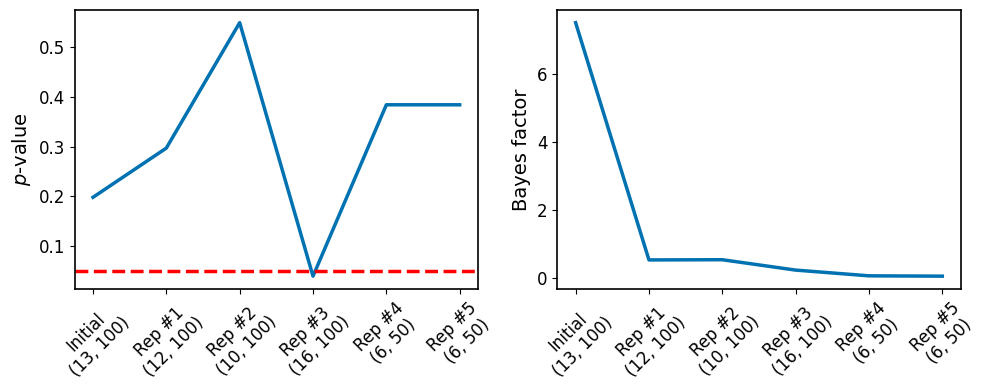

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].plot(p_values)
axes[0].axhline(0.05, linestyle="--", c="r")
axes[0].set_ylabel(r"$p$-value")
axes[0].set_xticks(
    [i for i in range(n_experiments)],
    [f"Initial\n{experiments[0]}"] + [f"Rep #{i + 1}\n{experiments[i + 1]}" for i in range(n_experiments - 1)],
    rotation=45,
)

axes[1].plot(bfs)
axes[1].set_ylabel("Bayes factor")
axes[1].set_xticks(
    [i for i in range(n_experiments)],
    [f"Initial\n{experiments[0]}"] + [f"Rep #{i + 1}\n{experiments[i + 1]}" for i in range(n_experiments - 1)],
    rotation=45,
)

plt.tight_layout()
plt.show()

# Working with posteriors

In [16]:
prior_a = 1
prior_b = 1

a = prior_a + k
b = prior_b + n - k

In [18]:
1 - beta(a, b).cdf(0.1)

0.9740139201225517

In [19]:
beta(a, b).cdf(0.05)

1.1130383903267853e-11